In [16]:
# =====================================================
# DESKRIPSI DATASET
# =====================================================
"""
Deskripsi Dataset
Dataset yang digunakan adalah data kesehatan pasien untuk memprediksi risiko stroke.
Dataset ini mencatat berbagai faktor risiko stroke seperti usia, hipertensi,
penyakit jantung, kadar glukosa, BMI, status merokok, dll.

Sumber: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

Atribut (kolom) yang terdapat dalam dataset ini mencakup:
- Identitas: id (ID unik pasien)
- Demografi: gender (jenis kelamin), age (usia), ever_married (pernah menikah)
- Kondisi Medis: hypertension (hipertensi), heart_disease (penyakit jantung)
- Gaya Hidup: smoking_status (status merokok), work_type (tipe pekerjaan)
- Lokasi: Residence_type (Urban/Rural)
- Pengukuran: avg_glucose_level (kadar glukosa rata-rata), bmi (Body Mass Index)
- Target: stroke (1=stroke, 0=tidak stroke)

Tujuan: Membangun model Klasifikasi Biner untuk memprediksi apakah seorang pasien
berisiko mengalami stroke atau tidak.
"""
# =====================================================

# =====================================================
# 1. IMPORT LIBRARY
# =====================================================

# Library utama untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Library untuk visualisasi data (membantu melihat distribusi data)
import matplotlib.pyplot as plt
import seaborn as sns

# Library dari scikit-learn untuk proses Machine Learning (Pre-processing)
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')



In [17]:

# =====================================================
# 2. LOAD DATA
# =====================================================

print("\n" + "=" * 60)
print("2. LOAD DATA")
print("=" * 60)

# 1. Memuat Dataset (menggunakan separator ';' karena file menggunakan delimiter titik koma)
df = pd.read_csv('/content/sample_data/healthcare-dataset-stroke-data.csv', sep=';')

# Menampilkan dimensi dataset (Jumlah Baris dan Kolom)
print(f"Dimensi Dataset: {df.shape[0]} Baris, {df.shape[1]} Kolom\n")
print("-" * 50)



2. LOAD DATA
Dimensi Dataset: 5110 Baris, 12 Kolom

--------------------------------------------------


In [18]:

# 2. Menampilkan 5 baris pertama untuk melihat bentuk fisik data
print("Tampilan 5 Baris Pertama:")
display(df.head())
print("-" * 50)

# 3. Pengecekan Tipe Data dan Jumlah Data yang Kosong (Non-Null Count)
print("Informasi Tipe Data dan Kolom:")
df.info()
print("-" * 50)



Tampilan 5 Baris Pertama:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


--------------------------------------------------
Informasi Tipe Data dan Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
--------------------------------------------------


In [19]:

# 2. Menampilkan 5 baris pertama untuk melihat bentuk fisik data
print("Tampilan 5 Baris Pertama:")
display(df.head())
print("-" * 50)


Tampilan 5 Baris Pertama:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


--------------------------------------------------


In [20]:


# 3. Pengecekan Tipe Data dan Jumlah Data yang Kosong (Non-Null Count)
print("Informasi Tipe Data dan Kolom:")
df.info()
print("-" * 50)



Informasi Tipe Data dan Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
--------------------------------------------------


In [21]:
# 4. Pengecekan Eksplisit Jumlah Missing Values (Data Kosong) per Kolom
print("Jumlah Data Kosong (Missing Values) per Kolom:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print("-" * 50)

Jumlah Data Kosong (Missing Values) per Kolom:
bmi    201
dtype: int64
--------------------------------------------------


In [22]:

# 5. Pengecekan Data Duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat dalam dataset: {duplicates}")
print("-" * 50)

Jumlah baris duplikat dalam dataset: 0
--------------------------------------------------


In [23]:
# 6. Ringkasan Statistik untuk Kolom Numerik
print("Ringkasan Statistik (Statistika Deskriptif):")
display(df.describe())

Ringkasan Statistik (Statistika Deskriptif):


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [24]:
# =====================================================
# 3. PRE-PROCESSING
# =====================================================

print("\n" + "=" * 60)
print("3. PRE-PROCESSING")
print("=" * 60)

# ------------------------------------------------
# 3.1 Menyalin Data Mentah & Mencegah Data Leakage
# ------------------------------------------------
# Menyalin data mentah dan menghapus kolom yang tidak diperlukan (ID karena hanya identifier)

from IPython.display import display

# Step 0: Copy Data
df_clean = df.copy()

print("\n=== SEBELUM STEP 1: Daftar Kolom Asli ===")
print(df_clean.columns.tolist())
print("-" * 50)

# Step 1: Drop Kolom (hapus 'id' karena hanya identifier unik)
kolom_dihapus = ['id']
df_clean = df_clean.drop(columns=kolom_dihapus)

print("=== SESUDAH STEP 1: Kolom Setelah Dihapus ===")
print(df_clean.columns.tolist())
print(f"Jumlah kolom berkurang menjadi: {df_clean.shape[1]} kolom")
display(df_clean.head(3))


3. PRE-PROCESSING

=== SEBELUM STEP 1: Daftar Kolom Asli ===
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
--------------------------------------------------
=== SESUDAH STEP 1: Kolom Setelah Dihapus ===
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
Jumlah kolom berkurang menjadi: 11 kolom


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1


In [ ]:

# ------------------------------------------------
# 3.2 Transformasi Target
# ------------------------------------------------
# Target sudah dalam bentuk biner (0/1), tidak perlu diubah
# Namun kita tetap cek distribusinya

print("\n=== STEP 2: Analisis Target (stroke) ===")
print("Kolom target: 'stroke' (1=Stroke, 0=Tidak Stroke)")
display(df_clean[['stroke']].head(3))

print("\nDistribusi Kelas Target:")
distribusi = df_clean['stroke'].value_counts()
persentase = df_clean['stroke'].value_counts(normalize=True) * 100
for kelas, jumlah, persen in zip(distribusi.index, distribusi.values, persentase.values):
    label = "Stroke" if kelas == 1 else "Tidak Stroke"
    print(f"- Kelas {kelas} ({label}): {jumlah} pasien ({persen:.2f}%)")


In [25]:

# ------------------------------------------------
# 3.3 Feature Engineering (Ekstraksi Fitur Baru)
# ------------------------------------------------
# Untuk dataset stroke, kita bisa membuat fitur baru yang bermanfaat

print("\n=== STEP 3: Feature Engineering (Ekstraksi Fitur Baru) ===")

# Buat kategori BMI berdasarkan standar WHO
def bmi_category(bmi):
    if pd.isna(bmi):
        return 'Unknown'
    elif bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_clean['bmi_category'] = df_clean['bmi'].apply(bmi_category)

# Buat kategori usia
def age_category(age):
    if age < 18:
        return 'Child'
    elif age < 40:
        return 'Young Adult'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

df_clean['age_category'] = df_clean['age'].apply(age_category)

# Buat fitur risiko gabungan (hipertensi + penyakit jantung)
df_clean['has_risk_factor'] = ((df_clean['hypertension'] == 1) | (df_clean['heart_disease'] == 1)).astype(int)

# Buat fitur interaksi usia dan risiko
df_clean['age_risk_interaction'] = df_clean['age'] * df_clean['has_risk_factor']

print("Fitur baru yang ditambahkan:")
print(f"- bmi_category: {df_clean['bmi_category'].unique().tolist()}")
print(f"- age_category: {df_clean['age_category'].unique().tolist()}")
print(f"- has_risk_factor: 0 atau 1 (memiliki hipertensi ATAU penyakit jantung)")
print(f"- age_risk_interaction: usia * has_risk_factor")
print("\nTampilan data setelah feature engineering:")
display(df_clean[['age', 'bmi', 'bmi_category', 'age_category', 'has_risk_factor', 'stroke']].head(5))


=== STEP 3: Feature Engineering (Ekstraksi Fitur Baru) ===
Fitur baru yang ditambahkan:
- bmi_category: ['Obese', 'Unknown', 'Normal', 'Overweight', 'Underweight']
- age_category: ['Senior', 'Adult', 'Young Adult', 'Child']
- has_risk_factor: 0 atau 1 (memiliki hipertensi ATAU penyakit jantung)
- age_risk_interaction: usia * has_risk_factor

Tampilan data setelah feature engineering:


,age,bmi,bmi_category,age_category,has_risk_factor,stroke
0,67.0,36.6,Obese,Senior,1,1
1,61.0,NaN,Unknown,Senior,0,1
2,80.0,32.5,Obese,Senior,1,1
3,49.0,34.4,Obese,Adult,0,1
4,79.0,24.0,Normal,Senior,1,1


In [26]:

# ------------------------------------------------
# 3.4 Menangani Data Kosong (Missing Values Imputation)
# ------------------------------------------------

print("\n=== STEP 4: Penanganan Missing Values ===")

print("Jumlah Data Kosong (Missing Values) SEBELUM penanganan:")
missing_sebelum = df_clean.isnull().sum()
print(missing_sebelum[missing_sebelum > 0])
print("-" * 50)

# Imputasi Numerik (Menggunakan Median - lebih robust terhadap outlier)
numeric_cols = ['bmi', 'avg_glucose_level']  # age tidak memiliki missing
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)
        print(f"Kolom '{col}': diisi dengan median = {median_value:.2f}")

# Imputasi Kategorikal (Menggunakan Modus/Mode)
categorical_cols = ['bmi_category', 'smoking_status']
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_value)
        print(f"Kolom '{col}': diisi dengan modus = '{mode_value}'")

print("\n=== SESUDAH STEP 4: Pengecekan Ulang Data Kosong ===")
missing_sesudah = df_clean.isnull().sum().sum()
print(f"Total Missing Values tersisa di seluruh dataset: {missing_sesudah}")
if missing_sesudah == 0:
    print("-> SUKSES: Data sudah bersih dari nilai kosong!")


=== STEP 4: Penanganan Missing Values ===
Jumlah Data Kosong (Missing Values) SEBELUM penanganan:
bmi    201
dtype: int64
--------------------------------------------------
Kolom 'bmi': diisi dengan median = 28.10

=== SESUDAH STEP 4: Pengecekan Ulang Data Kosong ===
Total Missing Values tersisa di seluruh dataset: 0
-> SUKSES: Data sudah bersih dari nilai kosong!



=== STEP 5: Visualisasi Data ===


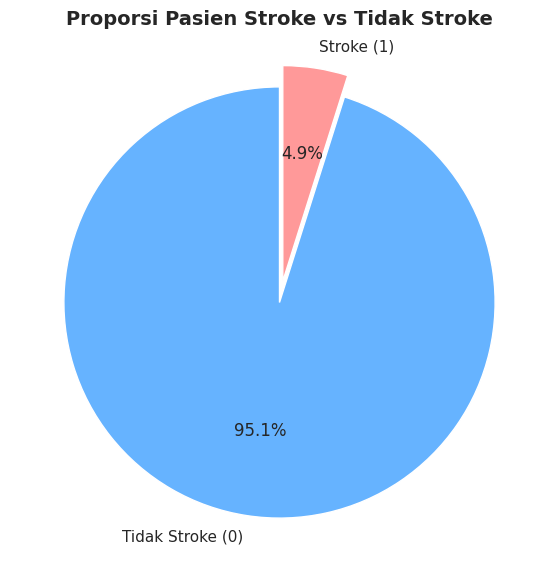

In [27]:
# ------------------------------------------------
# 3.5 Visualisasi Data
# ------------------------------------------------

print("\n=== STEP 5: Visualisasi Data ===")

# Buat DataFrame untuk visualisasi
df_vis = df_clean.copy()

# 1. Plot Distribusi Target
plt.figure(figsize=(7, 7))
stroke_counts = df_vis['stroke'].value_counts()
colors = ['#66b3ff', '#ff9999']
labels = ['Tidak Stroke (0)', 'Stroke (1)']
plt.pie(stroke_counts, labels=labels, autopct='%1.1f%%', colors=colors, explode=(0, 0.1), startangle=90)
plt.title('Proporsi Pasien Stroke vs Tidak Stroke', fontsize=14, fontweight='bold')
plt.show()


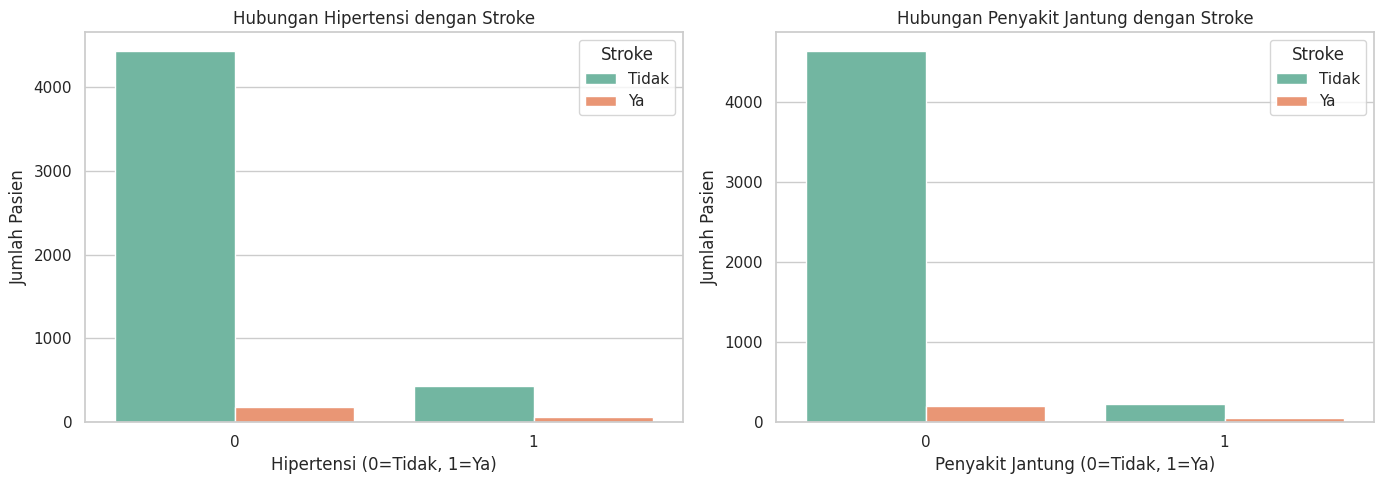

In [28]:

# 2. Plot Faktor Risiko Berdasarkan Status Stroke
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hipertensi
sns.countplot(data=df_vis, x='hypertension', hue='stroke', ax=axes[0], palette='Set2')
axes[0].set_title('Hubungan Hipertensi dengan Stroke')
axes[0].set_xlabel('Hipertensi (0=Tidak, 1=Ya)')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].legend(title='Stroke', labels=['Tidak', 'Ya'])

# Penyakit Jantung
sns.countplot(data=df_vis, x='heart_disease', hue='stroke', ax=axes[1], palette='Set2')
axes[1].set_title('Hubungan Penyakit Jantung dengan Stroke')
axes[1].set_xlabel('Penyakit Jantung (0=Tidak, 1=Ya)')
axes[1].set_ylabel('Jumlah Pasien')
axes[1].legend(title='Stroke', labels=['Tidak', 'Ya'])

plt.tight_layout()
plt.show()


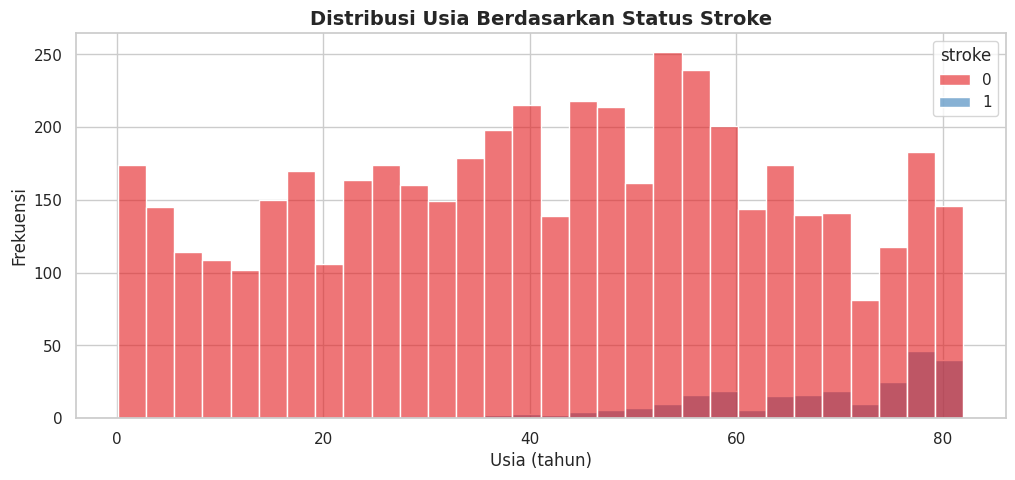

In [29]:

# 3. Plot Distribusi Usia berdasarkan Stroke
plt.figure(figsize=(12, 5))
sns.histplot(data=df_vis, x='age', hue='stroke', bins=30, alpha=0.6, palette='Set1')
plt.title('Distribusi Usia Berdasarkan Status Stroke', fontsize=14, fontweight='bold')
plt.xlabel('Usia (tahun)')
plt.ylabel('Frekuensi')
plt.show()

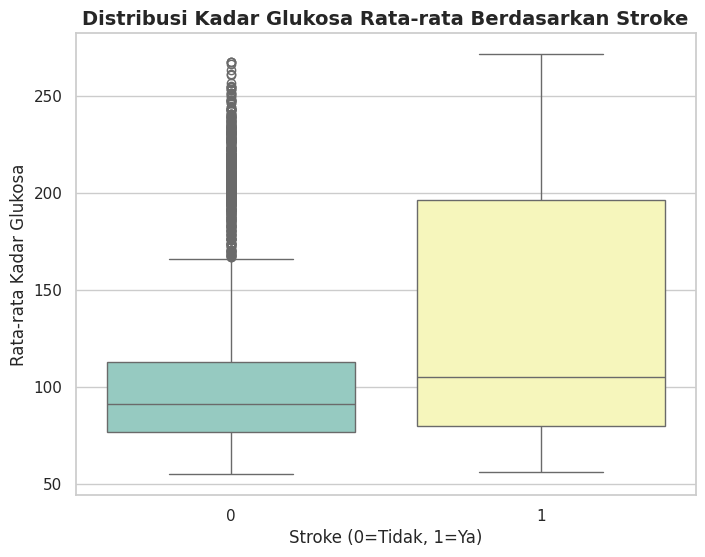

In [30]:

# 4. Plot Rata-rata Kadar Glukosa berdasarkan Stroke
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_vis, x='stroke', y='avg_glucose_level', palette='Set3')
plt.title('Distribusi Kadar Glukosa Rata-rata Berdasarkan Stroke', fontsize=14, fontweight='bold')
plt.xlabel('Stroke (0=Tidak, 1=Ya)')
plt.ylabel('Rata-rata Kadar Glukosa')
plt.show()


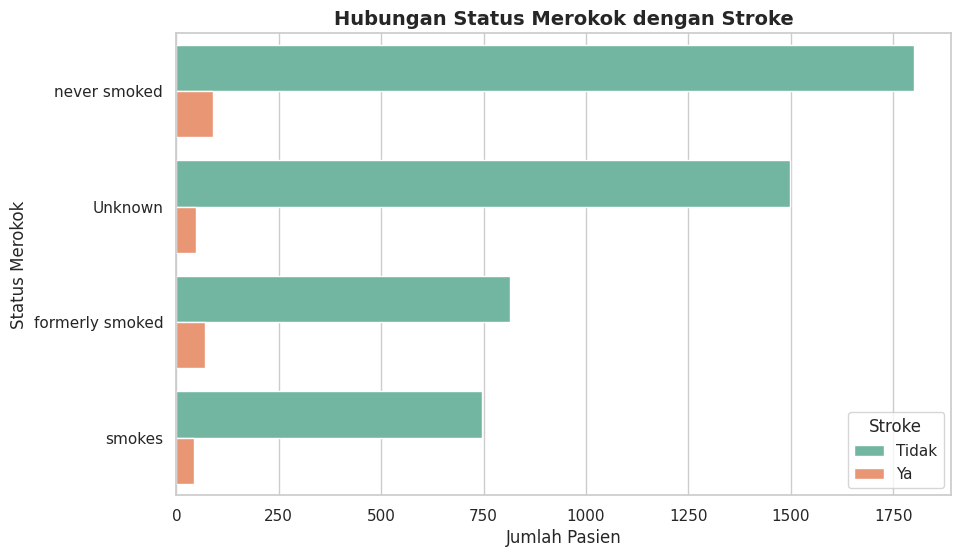

In [31]:
# 5. Plot Status Merokok vs Stroke
plt.figure(figsize=(10, 6))
smoking_order = df_vis['smoking_status'].value_counts().index
sns.countplot(data=df_vis, y='smoking_status', hue='stroke', order=smoking_order, palette='Set2')
plt.title('Hubungan Status Merokok dengan Stroke', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Pasien')
plt.ylabel('Status Merokok')
plt.legend(title='Stroke', labels=['Tidak', 'Ya'])
plt.show()

In [32]:

# ------------------------------------------------
# 3.6 Encoding Data Kategorikal (Teks ke Angka)
# ------------------------------------------------

print("\n=== STEP 6: Encoding Data Kategorikal (Teks ke Angka) ===")

print("Sampel Data Kategorikal SEBELUM encoding:")
display(df_clean[['gender', 'work_type', 'Residence_type', 'smoking_status', 'bmi_category', 'age_category']].head(3))
print("-" * 50)

# Simpan target terlebih dahulu
target = df_clean['stroke']

# Pilih kolom yang akan di-encode
binary_cols = ['gender', 'ever_married', 'Residence_type']
# gender: Female/Male (binary)
# ever_married: Yes/No (binary)
# Residence_type: Urban/Rural (binary)

multi_category_cols = ['work_type', 'smoking_status', 'bmi_category', 'age_category']



=== STEP 6: Encoding Data Kategorikal (Teks ke Angka) ===
Sampel Data Kategorikal SEBELUM encoding:


,gender,work_type,Residence_type,smoking_status,bmi_category,age_category
0,Male,Private,Urban,formerly smoked,Obese,Senior
1,Female,Self-employed,Rural,never smoked,Unknown,Senior
2,Male,Private,Rural,never smoked,Obese,Senior


--------------------------------------------------


In [33]:

# A. Binary Encoding (manual mapping)
print("Melakukan Binary Encoding untuk kolom:")
for col in binary_cols:
    unique_vals = df_clean[col].unique()
    print(f"- {col}: {unique_vals.tolist()}")

    # Mapping untuk binary columns
    if col == 'gender':
        df_clean[f'{col}_encoded'] = df_clean[col].map({'Male': 1, 'Female': 0, 'Other': 2})
    elif col == 'ever_married':
        df_clean[f'{col}_encoded'] = df_clean[col].map({'Yes': 1, 'No': 0})
    elif col == 'Residence_type':
        df_clean[f'{col}_encoded'] = df_clean[col].map({'Urban': 1, 'Rural': 0})

    df_clean = df_clean.drop(columns=[col])

Melakukan Binary Encoding untuk kolom:
- gender: ['Male', 'Female', 'Other']
- ever_married: ['Yes', 'No']
- Residence_type: ['Urban', 'Rural']


In [34]:
# B. One-Hot Encoding untuk multi-category columns
print(f"\nMelakukan One-Hot Encoding untuk kolom: {multi_category_cols}")
df_clean = pd.get_dummies(df_clean, columns=multi_category_cols, drop_first=True)

# Konversi boolean ke integer
for col in df_clean.columns:
    if df_clean[col].dtype == 'bool':
        df_clean[col] = df_clean[col].astype(int)

print(f"\n=== SESUDAH STEP 6: Data Teks Berubah Menjadi Angka ===")
print(f"Bentuk Dimensi Data Sekarang: {df_clean.shape[0]} Baris, {df_clean.shape[1]} Kolom")
print("Tampilan 3 Baris Pertama:")
display(df_clean.head(3))


Melakukan One-Hot Encoding untuk kolom: ['work_type', 'smoking_status', 'bmi_category', 'age_category']

=== SESUDAH STEP 6: Data Teks Berubah Menjadi Angka ===
Bentuk Dimensi Data Sekarang: 5110 Baris, 25 Kolom
Tampilan 3 Baris Pertama:


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,has_risk_factor,age_risk_interaction,gender_encoded,ever_married_encoded,...,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight,bmi_category_Unknown,age_category_Child,age_category_Senior,age_category_Young Adult
0,67.0,0,1,228.69,36.6,1,1,67.0,1,1,...,1,0,0,1,0,0,0,0,1,0
1,61.0,0,0,202.21,28.1,1,0,0.0,0,1,...,0,1,0,0,0,0,1,0,1,0
2,80.0,0,1,105.92,32.5,1,1,80.0,1,1,...,0,1,0,1,0,0,0,0,1,0


In [ ]:

# ------------------------------------------------
# 3.7 Pemisahan Data Latih dan Data Uji (Train-Test Split)
# ------------------------------------------------

print("\n=== STEP 7: Pemisahan Data Latih dan Data Uji ===")

X = df_clean.drop(columns=['stroke'])
y = df_clean['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("=== HASIL AKHIR STEP 7: Pemisahan Data ===")
print("Rincian Data Latih (Training Data):")
print(f"- Fitur Latih (X_train) : {X_train.shape[0]} baris, {X_train.shape[1]} kolom")
print(f"- Target Latih (y_train): {y_train.shape[0]} baris")
print(f"  - Stroke (1): {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"  - Tidak Stroke (0): {(y_train == 0).sum()} ({(1-y_train.mean())*100:.2f}%)")

print("\nRincian Data Uji (Testing Data):")
print(f"- Fitur Uji (X_test)    : {X_test.shape[0]} baris, {X_test.shape[1]} kolom")
print(f"- Target Uji (y_test)   : {y_test.shape[0]} baris")
print(f"  - Stroke (1): {y_test.sum()} ({y_test.mean()*100:.2f}%)")
print(f"  - Tidak Stroke (0): {(y_test == 0).sum()} ({(1-y_test.mean())*100:.2f}%)")

print("\n[!] Pre-processing Selesai dan Siap Digunakan untuk Modeling [!]")

In [35]:
# ------------------------------------------------
# 3.7 Pemisahan Data Latih dan Data Uji (Train-Test Split)
# ------------------------------------------------

print("\n=== STEP 7: Pemisahan Data Latih dan Data Uji ===")

X = df_clean.drop(columns=['stroke'])
y = df_clean['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("=== HASIL AKHIR STEP 7: Pemisahan Data ===")
print("Rincian Data Latih (Training Data):")
print(f"- Fitur Latih (X_train) : {X_train.shape[0]} baris, {X_train.shape[1]} kolom")
print(f"- Target Latih (y_train): {y_train.shape[0]} baris")
print(f"  - Stroke (1): {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"  - Tidak Stroke (0): {(y_train == 0).sum()} ({(1-y_train.mean())*100:.2f}%)")

print("\nRincian Data Uji (Testing Data):")
print(f"- Fitur Uji (X_test)    : {X_test.shape[0]} baris, {X_test.shape[1]} kolom")
print(f"- Target Uji (y_test)   : {y_test.shape[0]} baris")
print(f"  - Stroke (1): {y_test.sum()} ({y_test.mean()*100:.2f}%)")
print(f"  - Tidak Stroke (0): {(y_test == 0).sum()} ({(1-y_test.mean())*100:.2f}%)")

print("\n[!] Pre-processing Selesai dan Siap Digunakan untuk Modeling [!]")


=== STEP 7: Pemisahan Data Latih dan Data Uji ===
=== HASIL AKHIR STEP 7: Pemisahan Data ===
Rincian Data Latih (Training Data):
- Fitur Latih (X_train) : 4088 baris, 24 kolom
- Target Latih (y_train): 4088 baris
  - Stroke (1): 199 (4.87%)
  - Tidak Stroke (0): 3889 (95.13%)

Rincian Data Uji (Testing Data):
- Fitur Uji (X_test)    : 1022 baris, 24 kolom
- Target Uji (y_test)   : 1022 baris
  - Stroke (1): 50 (4.89%)
  - Tidak Stroke (0): 972 (95.11%)

[!] Pre-processing Selesai dan Siap Digunakan untuk Modeling [!]


In [36]:

# ------------------------------------------------
# 3.8 Standardisasi/Normalisasi Fitur Numerik (Opsional)
# ------------------------------------------------

print("\n=== STEP 8: Standardisasi Fitur Numerik (Opsional) ===")

# Identifikasi kolom numerik yang perlu distandardisasi
numeric_features = ['age', 'avg_glucose_level', 'bmi']
# Tambahkan juga kolom encoded binary dan hasil one-hot tidak perlu distandardisasi

print(f"Kolom numerik yang akan distandardisasi: {numeric_features}")

# Simpan data sebelum standardisasi untuk referensi
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Standardisasi berhasil dilakukan!")
print("Data siap digunakan untuk modeling dengan fitur yang telah distandardisasi.")



=== STEP 8: Standardisasi Fitur Numerik (Opsional) ===
Kolom numerik yang akan distandardisasi: ['age', 'avg_glucose_level', 'bmi']
Standardisasi berhasil dilakukan!
Data siap digunakan untuk modeling dengan fitur yang telah distandardisasi.


In [37]:

# =====================================================
# 4. MENYIMPAN DATA HASIL PRE-PROCESSING
# =====================================================

print("\n" + "=" * 60)
print("4. MENYIMPAN DATA HASIL PRE-PROCESSING")
print("=" * 60)

import os

# Simpan data sebelum standardisasi (tanpa scaling)
csv_filename = 'stroke_preprocessed.csv'
parquet_filename = 'stroke_preprocessed.parquet'

df_clean.to_csv(csv_filename, index=False)
df_clean.to_parquet(parquet_filename, index=False)

print(f"1. Berhasil menyimpan: {csv_filename}")
print(f"2. Berhasil menyimpan: {parquet_filename}")
print("-" * 50)

# Detail Perbandingan Ukuran File
size_csv = os.path.getsize(csv_filename) / (1024 * 1024)
size_parquet = os.path.getsize(parquet_filename) / (1024 * 1024)

print("DETAIL UKURAN FILE:")
print(f"- Ukuran File CSV     : {size_csv:.2f} MB")
print(f"- Ukuran File Parquet : {size_parquet:.2f} MB")
if size_csv > 0:
    print(f"- Efisiensi Ruang     : {((size_csv - size_parquet) / size_csv * 100):.1f}% lebih kecil")
print("-" * 50)
print("Data siap untuk diunduh dari folder 'Files' di sidebar kiri.")


4. MENYIMPAN DATA HASIL PRE-PROCESSING
1. Berhasil menyimpan: stroke_preprocessed.csv
2. Berhasil menyimpan: stroke_preprocessed.parquet
--------------------------------------------------
DETAIL UKURAN FILE:
- Ukuran File CSV     : 0.30 MB
- Ukuran File Parquet : 0.07 MB
- Efisiensi Ruang     : 77.6% lebih kecil
--------------------------------------------------
Data siap untuk diunduh dari folder 'Files' di sidebar kiri.


In [38]:

# =====================================================
# 5. DATA HASIL PRE-PROCESSING (TAMPILAN AKHIR)
# =====================================================

print("\n" + "=" * 60)
print("5. DATA HASIL PRE-PROCESSING")
print("=" * 60)

print(f"=== BENTUK AKHIR DATASET ===")
print(f"Total Baris : {df_clean.shape[0]} baris (Jumlah Pasien)")
print(f"Total Kolom : {df_clean.shape[1]} kolom (Fitur + 1 Target)")
print("-" * 50)

print("\n1. Tampilan 5 Baris Pertama (Fokus pada Fitur Utama & Target):")
kolom_utama = ['stroke', 'age', 'avg_glucose_level', 'bmi', 'gender_encoded', 'ever_married_encoded', 'Residence_type_encoded']
# Pastikan kolom ada
kolom_utama = [col for col in kolom_utama if col in df_clean.columns]
display(df_clean[kolom_utama].head())

print("-" * 50)
print("\n2. Tampilan 5 Baris Pertama (Fokus pada Hasil One-Hot Encoding):")
kolom_dummy = [col for col in df_clean.columns if 'work_type_' in col or 'smoking_status_' in col or 'bmi_category_' in col][:7]
if kolom_dummy:
    display(df_clean[kolom_dummy].head())
else:
    print("Tidak ada kolom one-hot encoding yang ditemukan")

print("-" * 50)
print("\n3. Pengecekan Tipe Data Akhir:")
print(df_clean.dtypes.value_counts())



5. DATA HASIL PRE-PROCESSING
=== BENTUK AKHIR DATASET ===
Total Baris : 5110 baris (Jumlah Pasien)
Total Kolom : 25 kolom (Fitur + 1 Target)
--------------------------------------------------

1. Tampilan 5 Baris Pertama (Fokus pada Fitur Utama & Target):


,stroke,age,avg_glucose_level,bmi,gender_encoded,ever_married_encoded,Residence_type_encoded
0,1,67.0,228.69,36.6,1,1,1
1,1,61.0,202.21,28.1,0,1,0
2,1,80.0,105.92,32.5,1,1,0
3,1,49.0,171.23,34.4,0,1,1
4,1,79.0,174.12,24.0,0,1,0


--------------------------------------------------

2. Tampilan 5 Baris Pertama (Fokus pada Hasil One-Hot Encoding):


,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,1,0,0,1,0,0
1,0,0,1,0,0,1,0
2,0,1,0,0,0,1,0
3,0,1,0,0,0,0,1
4,0,0,1,0,0,1,0


--------------------------------------------------

3. Pengecekan Tipe Data Akhir:
int64      21
float64     4
Name: count, dtype: int64


In [39]:
# =====================================================
# KESIMPULAN
# =====================================================

print("\n" + "=" * 60)
print("KESIMPULAN")
print("=" * 60)

print("""
Tahapan yang Dilakukan (Pre-Processing Steps):
1. Pencegahan Data Leakage (copy data, hapus kolom 'id')
2. Analisis Target (distribusi stroke vs tidak stroke)
3. Feature Engineering (BMI category, Age category, Risk factor, Interaction)
4. Penanganan Data Kosong (Imputasi median untuk numerik, modus untuk kategorikal)
5. Visualisasi Data (pie chart, bar plot, histogram, boxplot)
6. Encoding Data Teks ke Angka (Binary encoding + One-Hot Encoding)
7. Pemisahan Data Latih dan Uji (Train-Test Split 80:20 dengan stratify)
8. Standardisasi Fitur Numerik (Opsional - menggunakan StandardScaler)

Output:
- stroke_preprocessed.csv
- stroke_preprocessed.parquet
""")

print("=" * 60)
print("PRE-PROCESSING SELESAI! DATA SIAP UNTUK DIMODELING")
print("=" * 60)


KESIMPULAN

Tahapan yang Dilakukan (Pre-Processing Steps):
1. Pencegahan Data Leakage (copy data, hapus kolom 'id')
2. Analisis Target (distribusi stroke vs tidak stroke)
3. Feature Engineering (BMI category, Age category, Risk factor, Interaction)
4. Penanganan Data Kosong (Imputasi median untuk numerik, modus untuk kategorikal)
5. Visualisasi Data (pie chart, bar plot, histogram, boxplot)
6. Encoding Data Teks ke Angka (Binary encoding + One-Hot Encoding)
7. Pemisahan Data Latih dan Uji (Train-Test Split 80:20 dengan stratify)
8. Standardisasi Fitur Numerik (Opsional - menggunakan StandardScaler)

Output:
- stroke_preprocessed.csv
- stroke_preprocessed.parquet

PRE-PROCESSING SELESAI! DATA SIAP UNTUK DIMODELING
